In [1]:
import os
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis
import joblib
import pandas as pd
from scipy.stats import skew
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

# Make sure the output directories exist
os.makedirs(ENSEMBLE_DIR_PATH, exist_ok=True)
os.makedirs(MODELS_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

## 1. Load Historical Emissions Data, World Bank Indicators Data, and Policy Data

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "historical_total_emission_per_country.csv"))
# emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions_legacy.csv"))
emissions_df.head()

,iso_alpha_3,year,total_emissions
0,ABW,1970,0.036970
1,ABW,1971,0.041825
2,ABW,1972,0.052708
3,ABW,1973,0.057704
4,ABW,1974,0.056999


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12375 entries, 0 to 12374
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      12375 non-null  object 
 1   year             12375 non-null  int64  
 2   total_emissions  12375 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 290.2+ KB


In [7]:
# Check emissions max year
emissions_df['year'].max()

np.int64(2024)

In [8]:
# Load the wb indicators
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators_filtered.csv"))
wb_df.head()

,iso_alpha_3,year,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,gdp_per_capita_growth_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,ALB,1980,2.047964,41.13,2671997.0,23.957492,NaN,NaN,NaN,NaN,...,NaN,160.170940,48.98,40.802920,21.350365,NaN,NaN,NaN,NaN,NaN
1,ALB,1981,2.002974,42.77,2726056.0,23.810507,NaN,NaN,NaN,3.648649,...,NaN,138.435374,50.89,40.729927,21.459854,NaN,NaN,NaN,5.745635,NaN
2,ALB,1982,2.113272,44.14,2784278.0,20.072918,NaN,NaN,NaN,0.795840,...,NaN,179.966044,53.23,40.656934,21.496350,NaN,NaN,NaN,2.948597,NaN
3,ALB,1983,2.120885,48.08,2843960.0,18.852075,NaN,NaN,NaN,-1.016802,...,NaN,174.363328,59.51,40.510949,21.496350,NaN,NaN,NaN,1.104938,NaN
4,ALB,1984,2.103937,44.62,2904429.0,18.040331,NaN,NaN,NaN,-3.307497,...,NaN,159.592530,54.66,40.620438,21.496350,NaN,NaN,NaN,-1.251597,NaN


In [9]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7695 entries, 0 to 7694
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   pop_growth                                      7693 non-null   float64
 3   food_production_index                           7014 non-null   float64
 4   pop_total                                       7695 non-null   float64
 5   exports_pct_of_gdp                              6461 non-null   float64
 6   renewable_energy_output_pct                     4962 non-null   float64
 7   energy_use_kg_of_oil_equivalent_per_capita      4823 non-null   float64
 8   population_in_urban_agglomerations_over_1m_pct  5265 non-null   float64
 9   gdp_per_capita_growth_pct                

In [10]:
# check wb data max year
wb_df['year'].max()

np.int64(2024)

In [11]:
# load the policy index data
policy_indices = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_indices.csv"))
policy_indices.head()

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock
0,AFG,1971,1,0.25,0.1875
1,AFG,1972,2,0.50,0.3750
2,AFG,1973,3,0.75,0.5625
3,AFG,1974,4,1.00,0.7500
4,AFG,1975,5,1.25,0.9375


In [12]:
policy_indices["year"].max()

np.int64(2030)

## 2. Merge All Data

In [13]:
print("policy indices shape:", policy_indices.shape)
print("indicators shape:", wb_df.shape)
policies_and_indicators_df = pd.merge(policy_indices, wb_df, on=["iso_alpha_3", "year"], how="inner")
print("merged shape:", policies_and_indicators_df.shape)
policies_and_indicators_df.head()

policy indices shape: (9687, 5)
indicators shape: (7695, 25)
merged shape: (6454, 28)


,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,AGO,1980,10,2.50,1.8750,3.587940,17.72,8133872.0,NaN,NaN,...,NaN,5.793103,14.04,35.906794,2.326141,NaN,NaN,NaN,NaN,NaN
1,AGO,1981,11,2.75,2.0625,3.642460,16.64,8435607.0,NaN,NaN,...,NaN,4.172414,12.59,35.877116,2.326141,NaN,NaN,NaN,-4.400001,NaN
2,AGO,1982,12,3.00,2.2500,3.678035,16.78,8751648.0,NaN,NaN,...,NaN,1.724138,12.55,35.858667,2.326141,NaN,NaN,NaN,0.000000,NaN
3,AGO,1983,13,3.25,2.4375,3.716064,16.90,9082983.0,NaN,NaN,...,NaN,2.965517,12.55,35.837010,2.326141,NaN,NaN,NaN,4.200001,NaN
4,AGO,1984,14,3.50,2.6250,3.706036,17.20,9425917.0,NaN,NaN,...,NaN,2.410690,12.73,35.814550,2.326141,NaN,NaN,NaN,6.000002,NaN


In [14]:
# merge with emissions data
print("policies and indicators shape:", policies_and_indicators_df.shape)
print("emissions shape:", emissions_df.shape)
merged_df = pd.merge(policies_and_indicators_df, emissions_df, on=['iso_alpha_3', 'year'], how='inner')
print("final merged shape:", merged_df.shape)
merged_df.head()

policies and indicators shape: (6454, 28)
emissions shape: (12375, 3)
final merged shape: (6454, 29)


,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
0,AGO,1980,10,2.50,1.8750,3.587940,17.72,8133872.0,NaN,NaN,...,5.793103,14.04,35.906794,2.326141,NaN,NaN,NaN,NaN,NaN,26.308007
1,AGO,1981,11,2.75,2.0625,3.642460,16.64,8435607.0,NaN,NaN,...,4.172414,12.59,35.877116,2.326141,NaN,NaN,NaN,-4.400001,NaN,24.901662
2,AGO,1982,12,3.00,2.2500,3.678035,16.78,8751648.0,NaN,NaN,...,1.724138,12.55,35.858667,2.326141,NaN,NaN,NaN,0.000000,NaN,27.276840
3,AGO,1983,13,3.25,2.4375,3.716064,16.90,9082983.0,NaN,NaN,...,2.965517,12.55,35.837010,2.326141,NaN,NaN,NaN,4.200001,NaN,28.851607
4,AGO,1984,14,3.50,2.6250,3.706036,17.20,9425917.0,NaN,NaN,...,2.410690,12.73,35.814550,2.326141,NaN,NaN,NaN,6.000002,NaN,29.283552


In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6452 non-null   float64
 6   food_production_index                           6013 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              5674 non-null   float64
 9   renewable_energy_output_pct              

## 3. Data Cleaning

### Data Imputation

In [16]:
(
    merged_df
    .query("iso_alpha_3 == 'USA'")
    [["year", "fossil_fuel_energy_consumption_pct"]]
    .tail(15)
)


,year,fossil_fuel_energy_consumption_pct
6086,2010,84.123387
6087,2011,83.887674
6088,2012,83.944603
6089,2013,82.972888
6090,2014,83.401990
6091,2015,82.325816
6092,2016,0.000000
6093,2017,0.000000
6094,2018,0.000000
6095,2019,0.000000


In [17]:
merged_df[(merged_df["year"].isin([2022, 2023, 2024])) & (merged_df.iso_alpha_3 == "USA")].sort_values(by=["iso_alpha_3", "year"]).head(20)

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
6098,USA,2022,6967,5921.0,2640.2625,0.575745,100.86,334017321.0,11.784405,NaN,...,127.804791,92.96,46.082979,16.567975,NaN,NaN,33.866926,2.512375,NaN,6074.236155
6099,USA,2023,7597,6447.4,2872.9250,0.831493,NaN,336806231.0,11.184413,NaN,...,127.796948,NaN,46.082979,16.568992,NaN,NaN,33.866926,2.887556,NaN,5890.986428
6100,USA,2024,8240,6986.8,3112.8375,0.976422,NaN,340110988.0,11.107457,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.793001,NaN,5912.617724


In [18]:
merged_df[merged_df['iso_alpha_3'] == 'USA'].iloc[-1]

iso_alpha_3                                                         USA
year                                                               2024
policy_flow_raw_stock                                              8240
policy_flow_jur_stock                                            6986.8
policy_flow_jur_nlp_stock                                     3112.8375
pop_growth                                                     0.976422
food_production_index                                               NaN
pop_total                                                   340110988.0
exports_pct_of_gdp                                            11.107457
renewable_energy_output_pct                                         NaN
energy_use_kg_of_oil_equivalent_per_capita                          NaN
population_in_urban_agglomerations_over_1m_pct                46.846426
gdp_per_capita_growth_pct                                      1.794192
industry_pct_of_gdp                                             

In [19]:
# variables where zero is *never* a real value
pct_vars = [
    "forest_area_pct",
    "agricultural_land_pct",
    "arable_land_pct",
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
]

# variables where zero *could* be valid
level_vars = [
    "cereal_yield_kg_per_hectare",
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
]

share_vars = [
    "exports_pct_of_gdp",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
]


In [20]:
merged_df_cleaned = merged_df.sort_values(["iso_alpha_3", "year"]).copy()

merged_df_cleaned[pct_vars] = (
    merged_df_cleaned[pct_vars]
        .mask(merged_df_cleaned[pct_vars] <= 0)
)


In [21]:
def interpolate_slow(x):
    return (
        x.interpolate(
            method="linear",
            limit_direction="both",
            limit=10   # slow-moving structural vars
        )
    )

def interpolate_scale(x):
    return (
        x.interpolate(
            method="linear",
            limit_direction="both",
            limit=10
        )
    )

def interpolate_growth(x):
    return (
        x.interpolate(
            method="linear",
            limit=10
        )
    )


In [22]:
slow_vars = [
    "forest_area_pct",
    "agricultural_land_pct",
    "arable_land_pct",
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "cereal_yield_kg_per_hectare",
]

scale_vars = [
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
    "exports_pct_of_gdp",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
]

growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "food_production_index",
    "crop_production_index",
]

In [23]:
merged_df_cleaned[slow_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[slow_vars]
        .transform(interpolate_slow)
)

merged_df_cleaned[scale_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[scale_vars]
        .transform(interpolate_scale)
)

merged_df_cleaned[growth_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[growth_vars]
        .transform(interpolate_growth)
)


In [24]:
merged_df_cleaned[pct_vars] = (
    merged_df_cleaned[pct_vars].clip(lower=0.1, upper=100)
)


In [25]:
bad_zeros = (
    merged_df_cleaned
        .query("year >= 2015")[pct_vars]
        .eq(0)
        .any()
)

if bad_zeros.any():
    print("⚠️ Zero values detected after imputation:")
    print(bad_zeros[bad_zeros])


In [26]:
merged_df_cleaned.columns

Index(['iso_alpha_3', 'year', 'policy_flow_raw_stock', 'policy_flow_jur_stock',
       'policy_flow_jur_nlp_stock', 'pop_growth', 'food_production_index',
       'pop_total', 'exports_pct_of_gdp', 'renewable_energy_output_pct',
       'energy_use_kg_of_oil_equivalent_per_capita',
       'population_in_urban_agglomerations_over_1m_pct',
       'gdp_per_capita_growth_pct', 'industry_pct_of_gdp',
       'fossil_fuel_energy_consumption_pct', 'cereal_yield_kg_per_hectare',
       'electricity_consumption_kwh_per_capita', 'gdp_2021_ppp_intl_usd',
       'gdp_per_capita_2021_ppp_intl_usd',
       'fertilizer_consumption_kg_per_ha_arable_land', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct',
       'electricity_from_renewables_pct', 'renewable_energy_consumption_pct',
       'forest_area_pct', 'gdp_growth_pct', 'manufacturing_pct_of_gdp',
       'total_emissions'],
      dtype='object')

In [27]:
id_cols = ["iso_alpha_3", "year"]

value_cols = merged_df_cleaned.columns.difference(id_cols)

merged_df_cleaned[value_cols] = (
    merged_df_cleaned
        .sort_values(["iso_alpha_3", "year"])
        .groupby("iso_alpha_3")[value_cols]
        .ffill()
        .bfill()
)



In [28]:
merged_df.isna().mean().sort_values(ascending=False)

fossil_fuel_energy_consumption_pct                0.326309
electricity_consumption_kwh_per_capita            0.315463
energy_use_kg_of_oil_equivalent_per_capita        0.303533
renewable_energy_output_pct                       0.284785
population_in_urban_agglomerations_over_1m_pct    0.275488
electricity_from_renewables_pct                   0.267121
renewable_energy_consumption_pct                  0.218469
forest_area_pct                                   0.180508
manufacturing_pct_of_gdp                          0.161140
gdp_2021_ppp_intl_usd                             0.160211
gdp_per_capita_2021_ppp_intl_usd                  0.160211
exports_pct_of_gdp                                0.120855
industry_pct_of_gdp                               0.098698
crop_production_index                             0.068330
food_production_index                             0.068330
cereal_yield_kg_per_hectare                       0.065696
fertilizer_consumption_kg_per_ha_arable_land      0.0655

In [29]:
merged_df_cleaned.isna().mean().sort_values(ascending=False)

iso_alpha_3                                       0.0
cereal_yield_kg_per_hectare                       0.0
manufacturing_pct_of_gdp                          0.0
gdp_growth_pct                                    0.0
forest_area_pct                                   0.0
renewable_energy_consumption_pct                  0.0
electricity_from_renewables_pct                   0.0
arable_land_pct                                   0.0
agricultural_land_pct                             0.0
crop_production_index                             0.0
fertilizer_consumption_kg_per_ha_arable_land      0.0
gdp_per_capita_2021_ppp_intl_usd                  0.0
gdp_2021_ppp_intl_usd                             0.0
electricity_consumption_kwh_per_capita            0.0
fossil_fuel_energy_consumption_pct                0.0
year                                              0.0
industry_pct_of_gdp                               0.0
gdp_per_capita_growth_pct                         0.0
population_in_urban_agglomer

In [30]:
merged_df_cleaned[merged_df_cleaned['iso_alpha_3'] == 'USA'].iloc[-1]

iso_alpha_3                                                         USA
year                                                               2024
policy_flow_raw_stock                                              8240
policy_flow_jur_stock                                            6986.8
policy_flow_jur_nlp_stock                                     3112.8375
pop_growth                                                     0.976422
food_production_index                                            100.86
pop_total                                                   340110988.0
exports_pct_of_gdp                                            11.107457
renewable_energy_output_pct                                   20.273309
energy_use_kg_of_oil_equivalent_per_capita                  6363.500158
population_in_urban_agglomerations_over_1m_pct                46.846426
gdp_per_capita_growth_pct                                      1.794192
industry_pct_of_gdp                                           17

In [31]:
(
    merged_df_cleaned
    .query("iso_alpha_3 == 'USA'")
    [["year", "fertilizer_consumption_kg_per_ha_arable_land"]]
    .tail(15)
)

,year,fertilizer_consumption_kg_per_ha_arable_land
6086,2010,124.742074
6087,2011,130.282137
6088,2012,134.988067
6089,2013,135.673478
6090,2014,128.089248
6091,2015,129.184330
6092,2016,128.040032
6093,2017,127.967236
6094,2018,130.337685
6095,2019,130.085491


### Data Correctness

In [32]:
merged_df_cleaned.describe()

,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
count,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6.454000e+03,6454.000000,6454.000000,6454.000000,...,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000,6454.000000
mean,2004.594205,178.515184,146.314317,77.824415,1.590833,83.672273,4.088421e+07,37.034584,36.638402,2094.326089,...,152.100485,84.280491,39.553720,14.930922,5.324350,37.570979,31.717433,3.371002,13.354605,245.794376
std,12.254116,406.985350,359.993794,173.638651,1.655753,35.301818,1.399758e+08,27.306742,35.022198,2691.727362,...,327.764649,32.292984,22.031808,14.181504,9.672631,31.956477,23.285915,5.682826,6.669462,959.508193
min,1980.000000,1.000000,0.250000,0.150000,-27.470786,3.080000,6.114800e+04,0.005377,0.000000,0.000000,...,0.000000,5.620000,0.436116,0.100000,0.100000,0.100000,0.100000,-64.047107,0.000000,0.026206
25%,1995.000000,22.000000,9.500000,6.250000,0.561921,63.465000,3.401272e+06,19.923264,4.538669,426.349494,...,10.336364,62.420000,21.109751,3.289660,0.170031,8.100000,11.482660,1.349561,8.425381,11.462687
50%,2006.000000,56.000000,35.000000,21.437500,1.541919,89.040000,9.549998e+06,30.766973,23.851632,1025.063478,...,67.842887,88.285000,40.437527,10.595386,1.391965,28.600000,29.180908,3.662356,12.849797,37.539246
75%,2015.000000,151.000000,115.037500,66.375000,2.538154,101.175000,2.889462e+07,46.268753,64.888456,2705.726922,...,166.451499,102.097500,56.744871,21.945137,5.655793,65.700000,48.209289,5.890445,17.503713,130.117861
max,2024.000000,8240.000000,6986.800000,3112.837500,21.700343,754.480000,1.450936e+09,228.993771,100.000000,21557.475076,...,5600.000000,452.440000,86.475816,73.388646,97.277228,98.300000,95.714627,86.826748,44.980398,15536.121680


In [33]:
# check if there are negative values in the fields
for col in merged_df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if (merged_df_cleaned[col] < 0).any():
        print(f"Column {col} has negative values.")

Column pop_growth has negative values.
Column gdp_per_capita_growth_pct has negative values.
Column gdp_growth_pct has negative values.


In [34]:
bounded_pct_vars = [
    "fossil_fuel_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "renewable_energy_consumption_pct",  # if present
]

merged_df_cleaned[bounded_pct_vars] = (
    merged_df_cleaned[bounded_pct_vars]
        .clip(lower=0, upper=100)
)

In [35]:
for col in bounded_pct_vars:
    print(col, merged_df_cleaned[col].min(), merged_df_cleaned[col].max())


fossil_fuel_energy_consumption_pct 1.63945200273131 99.9943048215969
electricity_from_renewables_pct 0.1 97.2772277227723
renewable_energy_consumption_pct 0.1 98.3


In [36]:
# Check negative emissions
negative_emissions_df = merged_df_cleaned[merged_df_cleaned["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array([], dtype=object)

In [37]:
# Check for duplicates
duplicates_df = merged_df_cleaned[merged_df_cleaned.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, policy_flow_raw_stock, policy_flow_jur_stock, policy_flow_jur_nlp_stock, pop_growth, food_production_index, pop_total, exports_pct_of_gdp, renewable_energy_output_pct, energy_use_kg_of_oil_equivalent_per_capita, population_in_urban_agglomerations_over_1m_pct, gdp_per_capita_growth_pct, industry_pct_of_gdp, fossil_fuel_energy_consumption_pct, cereal_yield_kg_per_hectare, electricity_consumption_kwh_per_capita, gdp_2021_ppp_intl_usd, gdp_per_capita_2021_ppp_intl_usd, fertilizer_consumption_kg_per_ha_arable_land, crop_production_index, agricultural_land_pct, arable_land_pct, electricity_from_renewables_pct, renewable_energy_consumption_pct, forest_area_pct, gdp_growth_pct, manufacturing_pct_of_gdp, total_emissions]
Index: []

[0 rows x 29 columns]


In [38]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = merged_df_cleaned["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)
iso_alpha_3_counts.head()

,iso_alpha_3,count
0,AGO,45
55,NPL,45
63,BOL,45
62,ESP,45
61,COM,45


In [39]:
# # how many countries have less than x records?
# x = 23
# countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
# print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
# print(countries_with_less_than_x_records)

In [40]:
# # Remove the countries with less than x records from the indicators_and_emissions_df
# countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
# indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
# indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [41]:
# Check the max year for every country
max_year_df = merged_df_cleaned.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2024]


In [42]:
merged_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6454 non-null   float64
 6   food_production_index                           6454 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              6454 non-null   float64
 9   renewable_energy_output_pct              

## 4. EDA 1

In [43]:
training_df = merged_df_cleaned.copy()

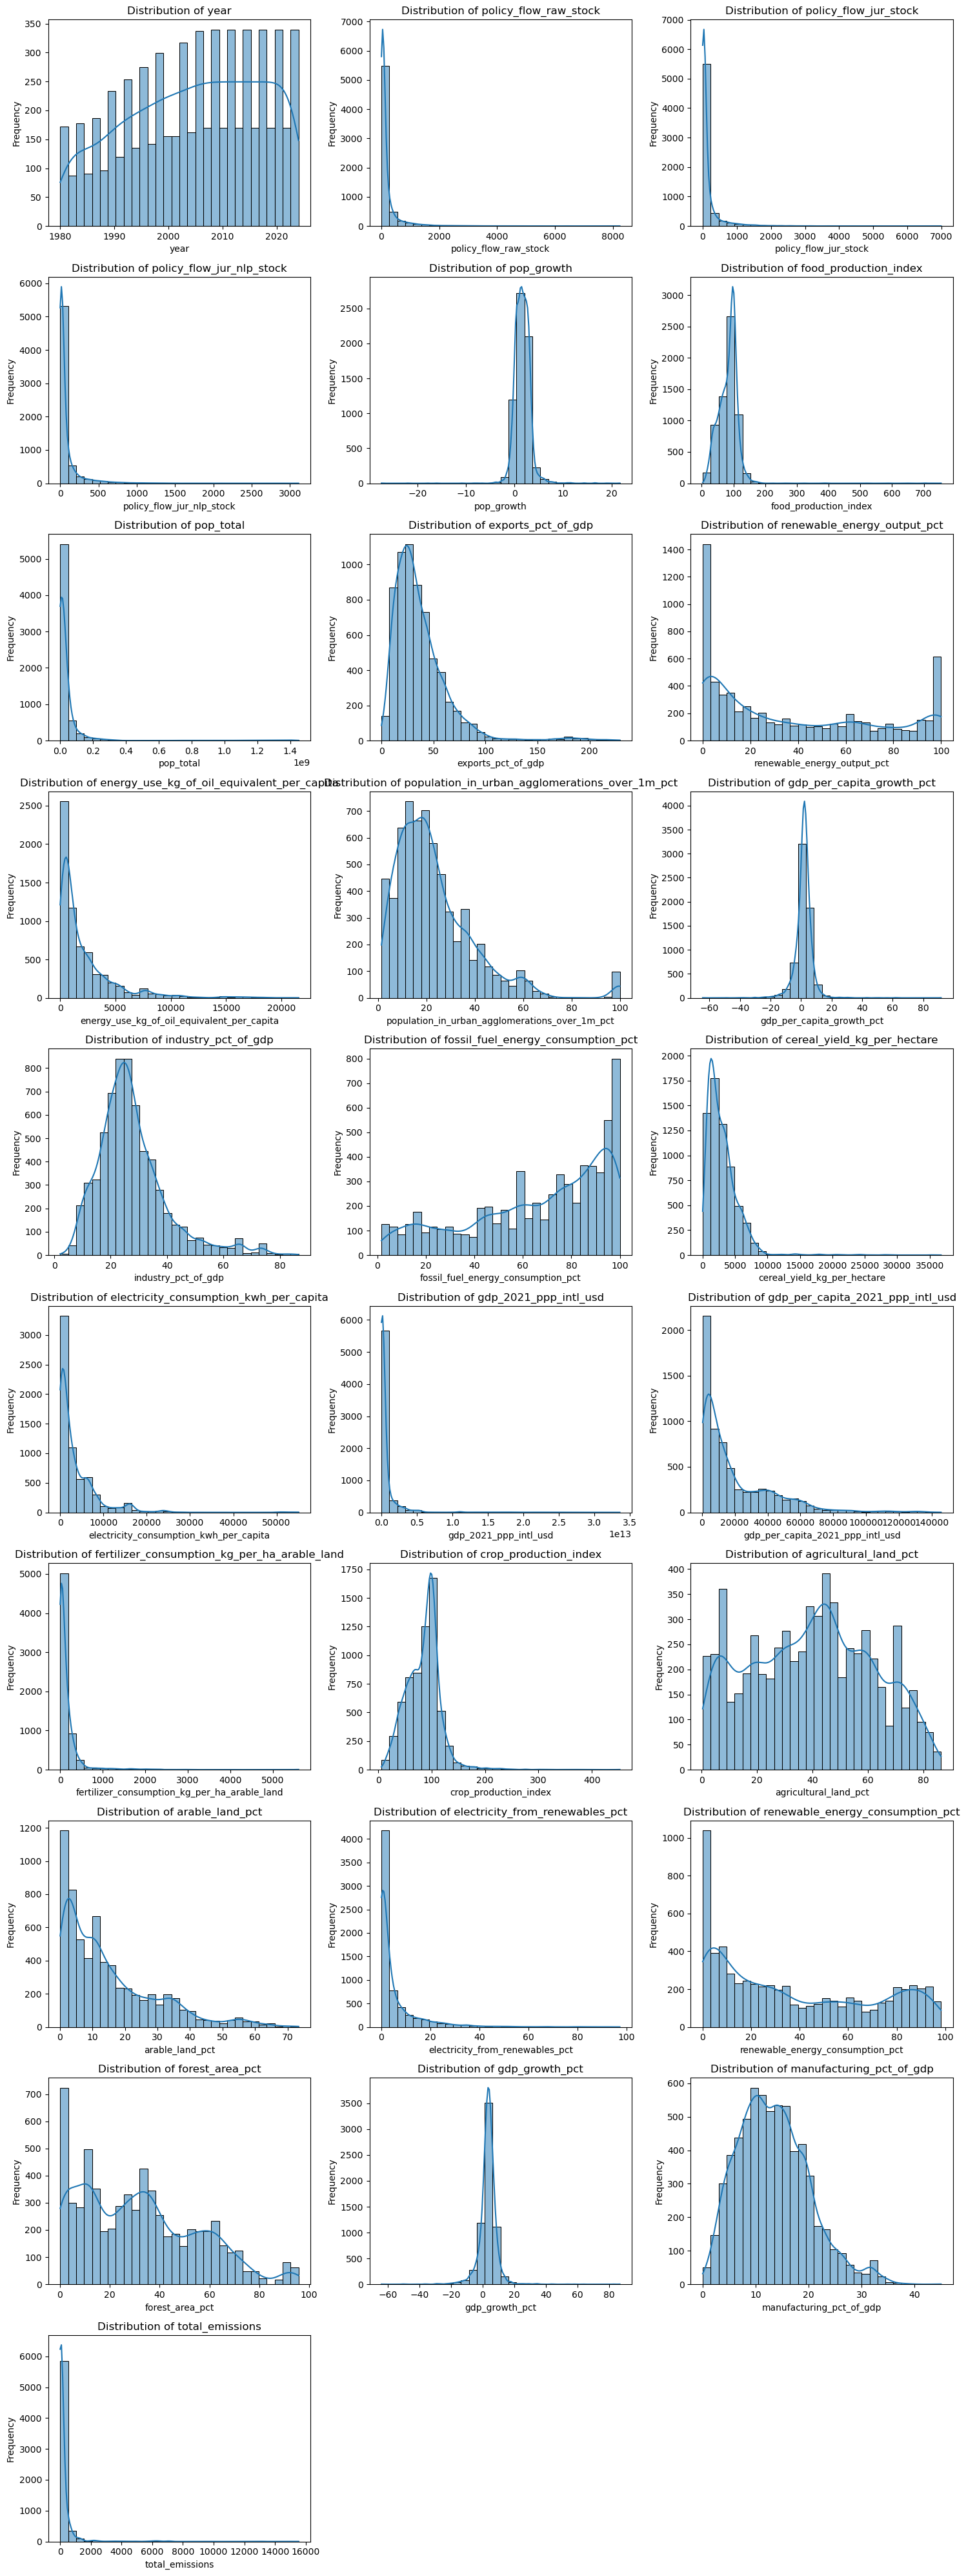

In [44]:
eda_utils.plot_numeric_fields_distributions(training_df)

In [45]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6454 non-null   float64
 6   food_production_index                           6454 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              6454 non-null   float64
 9   renewable_energy_output_pct              

### Check correlation and skewness

In [46]:
target = "total_emissions"
features = [
    c for c in training_df.columns
    if c not in ["iso_alpha_3", "year", target]
]


In [47]:
def within_country_corr(df, features, target):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        if g[target].notna().sum() < 5:
            continue  # too few observations

        for f in features:
            valid = g[[f, target]].dropna()
            if len(valid) < 5:
                continue

            corr = valid[f].corr(valid[target])
            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "corr": corr
            })

    return pd.DataFrame(out)


In [48]:
corr_df = within_country_corr(
    training_df, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

In [49]:
corr_summary

,median_corr,mean_corr,abs_median_corr,n_countries
feature,,,,
pop_total,9.057153e-01,0.538821,0.921454,170
gdp_2021_ppp_intl_usd,8.879205e-01,0.566674,0.893223,170
policy_flow_raw_stock,8.416329e-01,0.458384,0.876378,170
policy_flow_jur_nlp_stock,8.436691e-01,0.455849,0.874783,170
policy_flow_jur_stock,8.375792e-01,0.452625,0.867958,170
food_production_index,7.937640e-01,0.551453,0.800653,170
crop_production_index,7.051517e-01,0.501038,0.748747,170
renewable_energy_output_pct,-4.103832e-01,-0.200139,0.649274,170
fertilizer_consumption_kg_per_ha_arable_land,5.032662e-01,0.361374,0.569959,170


### Check Skewness

In [50]:
def within_country_skew(df, features):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        for f in features:
            x = g[f].dropna()
            if len(x) < 5:
                continue

            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "skewness": skew(x)
            })

    return pd.DataFrame(out)


In [51]:
skew_df = within_country_skew(
    training_df, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)


/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_9492/2906196379.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": skew(x)


In [52]:
corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
pop_total,9.057153e-01,0.538821,0.921454,170,0.082130,0.077611,0.320130,170
gdp_2021_ppp_intl_usd,8.879205e-01,0.566674,0.893223,170,0.396444,0.388246,NaN,167
policy_flow_raw_stock,8.416329e-01,0.458384,0.876378,170,0.960675,0.950596,0.960675,170
policy_flow_jur_nlp_stock,8.436691e-01,0.455849,0.874783,170,0.945313,0.947800,0.945313,170
policy_flow_jur_stock,8.375792e-01,0.452625,0.867958,170,1.017626,1.012919,1.017626,170
food_production_index,7.937640e-01,0.551453,0.800653,170,0.248600,0.188826,0.421265,170
crop_production_index,7.051517e-01,0.501038,0.748747,170,0.198325,0.203300,0.362833,170
renewable_energy_output_pct,-4.103832e-01,-0.200139,0.649274,170,0.309503,0.211586,0.625511,170
fertilizer_consumption_kg_per_ha_arable_land,5.032662e-01,0.361374,0.569959,170,0.514423,0.591897,0.575940,170


## 5. Feature Engineering for Numeric Features

In [53]:
log_vars = [
    "pop_total",
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
]
policy_vars = [
    "policy_flow_raw_stock",
    "policy_flow_jur_stock",
    "policy_flow_jur_nlp_stock",
]
share_vars = [
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
    "exports_pct_of_gdp",
    "renewable_energy_output_pct"
]
agri_log_vars = [
    "cereal_yield_kg_per_hectare",
    "fertilizer_consumption_kg_per_ha_arable_land",
]

agri_level_vars = [
    "food_production_index",
    "crop_production_index",
    "agricultural_land_pct",
    "arable_land_pct",
    "forest_area_pct",
]
growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "pop_growth",
]


In [54]:
training_df_transformed = training_df.copy()

In [55]:
# apply log transformation
for v in log_vars + policy_vars + agri_log_vars:
    training_df_transformed[f"log_{v}"] = np.log1p(training_df_transformed[v])


In [56]:
# Clip share 
bounded_vars = share_vars + agri_level_vars

training_df_transformed[bounded_vars] = (
    training_df_transformed[bounded_vars]
        .clip(lower=0, upper=100)
)


In [57]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'policy_flow_raw_stock', 'policy_flow_jur_stock',
       'policy_flow_jur_nlp_stock', 'pop_growth', 'food_production_index',
       'pop_total', 'exports_pct_of_gdp', 'renewable_energy_output_pct',
       'energy_use_kg_of_oil_equivalent_per_capita',
       'population_in_urban_agglomerations_over_1m_pct',
       'gdp_per_capita_growth_pct', 'industry_pct_of_gdp',
       'fossil_fuel_energy_consumption_pct', 'cereal_yield_kg_per_hectare',
       'electricity_consumption_kwh_per_capita', 'gdp_2021_ppp_intl_usd',
       'gdp_per_capita_2021_ppp_intl_usd',
       'fertilizer_consumption_kg_per_ha_arable_land', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct',
       'electricity_from_renewables_pct', 'renewable_energy_consumption_pct',
       'forest_area_pct', 'gdp_growth_pct', 'manufacturing_pct_of_gdp',
       'total_emissions', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'lo

In [58]:
final_features = (
    [f"log_{v}" for v in log_vars] +
    [f"log_{v}" for v in policy_vars] +
    [f"log_{v}" for v in agri_log_vars] +
    share_vars +
    agri_level_vars +
    growth_vars
)

target = ["total_emissions"]
fixed_effect = ["iso_alpha_3"]
time_var = ["year"]

fields_to_keep = fixed_effect + time_var + final_features + target

In [59]:
# Assert physical plausibility (ignore NaNs)
for col in bounded_vars:
    assert training_df_transformed[col].dropna().min() >= 0, f"Negative values in {col}"
    assert training_df_transformed[col].dropna().max() <= 100, f"Values >100 in {col}"


In [60]:
# No infinite logs
assert np.isfinite(training_df_transformed[final_features].dropna()).all().all()


In [61]:
# Feature availability
training_df_transformed[final_features].isna().mean().sort_values(ascending=False)

log_pop_total                                       0.0
log_gdp_2021_ppp_intl_usd                           0.0
gdp_per_capita_growth_pct                           0.0
gdp_growth_pct                                      0.0
forest_area_pct                                     0.0
arable_land_pct                                     0.0
agricultural_land_pct                               0.0
crop_production_index                               0.0
food_production_index                               0.0
renewable_energy_output_pct                         0.0
exports_pct_of_gdp                                  0.0
manufacturing_pct_of_gdp                            0.0
industry_pct_of_gdp                                 0.0
population_in_urban_agglomerations_over_1m_pct      0.0
electricity_from_renewables_pct                     0.0
renewable_energy_consumption_pct                    0.0
fossil_fuel_energy_consumption_pct                  0.0
log_fertilizer_consumption_kg_per_ha_arable_land

In [62]:
training_df_transformed = training_df_transformed[fields_to_keep]

In [63]:
# create log target (idempotent)
training_df_transformed["log_total_emissions"] = np.log1p(training_df_transformed["total_emissions"])

In [64]:
print(training_df_transformed["log_total_emissions"].max())
print(training_df_transformed["log_total_emissions"].min())

9.650987386689062
0.025868037800097013


In [65]:
# drop renewable_energy_output_pct due to high missingness
training_df_transformed = training_df_transformed.drop(
    columns=["renewable_energy_output_pct"],
    errors="ignore"
)


In [66]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_energy_use_kg_of_oil_equivalent_per_capita',
       'log_electricity_consumption_kwh_per_capita',
       'log_policy_flow_raw_stock', 'log_policy_flow_jur_stock',
       'log_policy_flow_jur_nlp_stock', 'log_cereal_yield_kg_per_hectare',
       'log_fertilizer_consumption_kg_per_ha_arable_land',
       'fossil_fuel_energy_consumption_pct',
       'renewable_energy_consumption_pct', 'electricity_from_renewables_pct',
       'population_in_urban_agglomerations_over_1m_pct', 'industry_pct_of_gdp',
       'manufacturing_pct_of_gdp', 'exports_pct_of_gdp',
       'food_production_index', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct', 'forest_area_pct',
       'gdp_growth_pct', 'gdp_per_capita_growth_pct', 'pop_growth',
       'total_emissions', 'log_total_emissions'],
      dtype='object')

## 6. EDA 2

In [67]:
target = "log_total_emissions"
features = [
    c for c in training_df_transformed.columns
    if c not in ["iso_alpha_3", "year", target]
]

corr_df = within_country_corr(
    training_df_transformed, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)



skew_df = within_country_skew(
    training_df_transformed, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)

corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
total_emissions,9.960981e-01,0.992742,0.996098,170,0.086128,0.174587,0.348427,170
log_policy_flow_jur_stock,9.069458e-01,0.527351,0.914946,170,-0.205667,-0.236513,0.303945,170
log_pop_total,9.011889e-01,0.544774,0.914094,170,-0.128987,-0.137422,0.239863,170
log_policy_flow_jur_nlp_stock,9.070275e-01,0.525385,0.913202,170,-0.219429,-0.224726,0.292718,170
log_policy_flow_raw_stock,9.075488e-01,0.526121,0.910941,170,-0.221776,-0.293314,0.307527,170
food_production_index,8.032539e-01,0.558794,0.803254,170,-0.234361,-0.481293,0.430364,170
log_gdp_per_capita_2021_ppp_intl_usd,7.299502e-01,0.451682,0.784467,170,-0.009923,-0.005017,NaN,167
crop_production_index,7.114709e-01,0.512671,0.726319,170,-0.327120,-0.571414,0.514942,170
log_fertilizer_consumption_kg_per_ha_arable_land,5.242920e-01,0.352643,0.577890,170,-0.183439,-0.209524,0.403354,170


## 7. ML

In [68]:
training_df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   iso_alpha_3                                       6454 non-null   object 
 1   year                                              6454 non-null   int64  
 2   log_pop_total                                     6454 non-null   float64
 3   log_gdp_2021_ppp_intl_usd                         6454 non-null   float64
 4   log_gdp_per_capita_2021_ppp_intl_usd              6454 non-null   float64
 5   log_energy_use_kg_of_oil_equivalent_per_capita    6454 non-null   float64
 6   log_electricity_consumption_kwh_per_capita        6454 non-null   float64
 7   log_policy_flow_raw_stock                         6454 non-null   float64
 8   log_policy_flow_jur_stock                         6454 non-null   float64
 9   log_policy_flow_jur

In [69]:
# Make sure the df is sorted by iso_alpha_3 and year
training_df_transformed = training_df_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [70]:
training_df_transformed[features].isna().mean().sort_values(ascending=False).head()


log_pop_total                0.0
log_gdp_2021_ppp_intl_usd    0.0
pop_growth                   0.0
gdp_per_capita_growth_pct    0.0
gdp_growth_pct               0.0
dtype: float64

In [71]:
training_df_transformed["log_total_emissions"].describe()

count    6454.000000
mean        3.725789
std         1.813781
min         0.025868
25%         2.522739
50%         3.651676
75%         4.876096
max         9.650987
Name: log_total_emissions, dtype: float64

In [72]:
training_df["year"].min(), training_df["year"].max()

(np.int64(1980), np.int64(2024))

In [75]:
features.remove("total_emissions")

In [76]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df_transformed.drop(columns=["total_emissions"]),
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=features
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3555          nan
RandomForest          0.4834       0.4043
XGBoost               0.4314       0.3636
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1061         0.1494            0.1391            0.1877               22.13               39.93
RandomForest            0.0184         0.2161            0.0318            0.3479                3.94               56.31
XGBoost                 0.0253         0.1615            0.0339            0.2249                5.24               67.62
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.1060623703214553,
  'test_mae_log': 0.14939174905662464,
  'train_rmse_log': np.float64(0.1391369485384316),
  'test_rmse_log': np.float64(0.18769597031404725),
  'train_mae_level': np.float64(22.128242344104734),
  'test_mae_level': np.float64(39.92645314076598)},
 'RandomForest': {'train_mae_log': 0.018376719458683653,
  'test_mae_log': 0.21611487262084644,
  'train_rmse_log': np.float64(0.03176715110936915),
  'test_rmse_log': np.float64(0.3479251596148642),
  'train_mae_level': np.float64(3.9409861703863873),
  'test_mae_level': np.float64(56.30845549979191)},
 'XGBoost': {'train_mae_log': 0.025294521435741128,
  'test_mae_log': 0.16151527909644564,
  'train_rmse_log': np.float64(0.03387568482327579),
  'test_rmse_log': np.float64(0.22491436634371037),
  'train_mae_level': np.float64(5.236925878629639),
  'test_mae_level': np.float64(67.6221208090053)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train

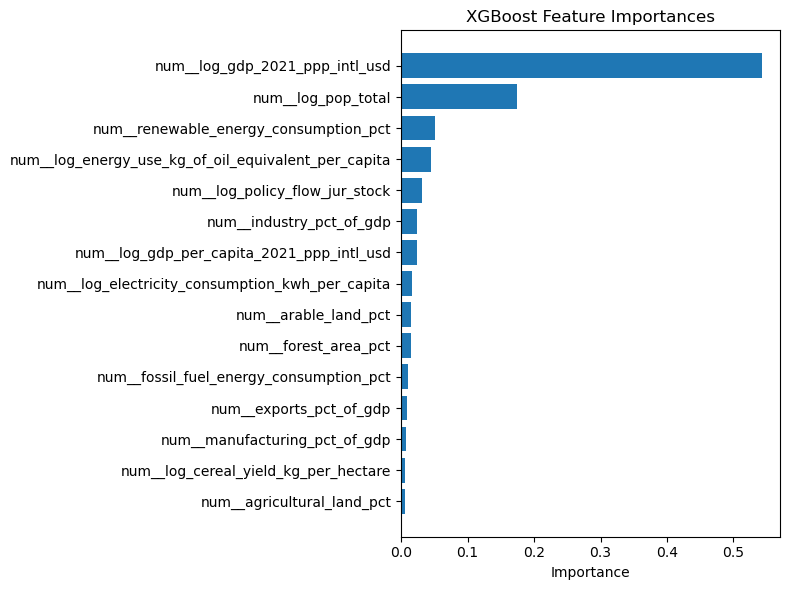

In [77]:
ra.plot_feature_importances(model="XGBoost", top_n=15)

In [78]:
# Table
country_errors = ra.per_country_errors(model="XGBoost")
country_errors.sort_values(by="mae_level", ascending=False)


,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
166,CHN,6,0.532785,0.544311,6102.914712
169,IDN,6,0.691287,0.699761,1139.970487
126,IND,6,0.223181,0.266759,780.282474
22,USA,6,0.047606,0.059596,292.045011
141,MEX,6,0.271929,0.301484,217.661528
...,...,...,...,...,...
10,BRB,6,0.030196,0.035855,0.057349
13,GRD,6,0.035813,0.039446,0.043529
4,DMA,6,0.021206,0.025740,0.024004
2,KIR,6,0.015528,0.019727,0.017068


In [79]:


# # Plot
# ra.plot_per_country_errors(model="XGBoost", metric="mae_log", top_k=25)
# ra.plot_per_country_errors(model="XGBoost", metric="mae_level", top_k=25)


In [80]:
# Table
policy_country = ra.policy_effect_by_country(model="XGBoost")
policy_country

,iso_alpha_3,mean_delta_log,mean_delta_level,median_delta_level,n_obs
0,MLT,-0.341961,-1.909628,-2.029402,6
1,ISL,-0.174146,-1.256078,-1.113435,6
2,NAM,-0.150145,-2.043098,-2.288147,6
3,UZB,-0.095267,-21.210409,-21.661354,6
4,TUN,-0.094147,-4.539400,-4.373512,6
...,...,...,...,...,...
165,GUY,0.188769,2.263164,2.498287,6
166,IRN,0.193018,139.320663,107.527557,6
167,QAT,0.209821,25.403679,25.479801,6
168,USA,0.226601,1270.345947,1264.243896,6


In [81]:
# # Table
# policy_country = ra.policy_effect_by_country(model="XGBoost")
# policy_country.head()

# # Plot
# ra.plot_policy_effects(model="XGBoost", top_k=25)


### Retraining 15 features

In [82]:
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "")
top_15_preds = [f"{clean_feature_name(f)}" for f in ra.top_n_features("XGBoost", 15)]
top_15_preds


['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'renewable_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_policy_flow_jur_stock',
 'industry_pct_of_gdp',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_electricity_consumption_kwh_per_capita',
 'arable_land_pct',
 'forest_area_pct',
 'fossil_fuel_energy_consumption_pct',
 'exports_pct_of_gdp',
 'manufacturing_pct_of_gdp',
 'log_cereal_yield_kg_per_hectare',
 'agricultural_land_pct']

In [83]:
retraining_fields_top15 = fixed_effect + time_var + top_15_preds  + [target, "total_emissions"]
retraining_fields_top15


['iso_alpha_3',
 'year',
 'log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'renewable_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_policy_flow_jur_stock',
 'industry_pct_of_gdp',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_electricity_consumption_kwh_per_capita',
 'arable_land_pct',
 'forest_area_pct',
 'fossil_fuel_energy_consumption_pct',
 'exports_pct_of_gdp',
 'manufacturing_pct_of_gdp',
 'log_cereal_yield_kg_per_hectare',
 'agricultural_land_pct',
 'log_total_emissions',
 'total_emissions']

In [84]:
retraining_df_top15_preds = training_df_transformed[retraining_fields_top15].copy()
# retraining_df_top15_preds = retraining_df_top15_preds.drop(columns=["log_policy_flow_raw_stock"])
# remove log_policy_flow_raw_stock from top_15_preds
# top_15_preds.remove("log_policy_flow_raw_stock")

retraining_df_top15_preds.head()

,iso_alpha_3,year,log_gdp_2021_ppp_intl_usd,log_pop_total,renewable_energy_consumption_pct,log_energy_use_kg_of_oil_equivalent_per_capita,log_policy_flow_jur_stock,industry_pct_of_gdp,log_gdp_per_capita_2021_ppp_intl_usd,log_electricity_consumption_kwh_per_capita,arable_land_pct,forest_area_pct,fossil_fuel_energy_consumption_pct,exports_pct_of_gdp,manufacturing_pct_of_gdp,log_cereal_yield_kg_per_hectare,agricultural_land_pct,log_total_emissions,total_emissions
0,AGO,1980,25.301042,15.911548,72.3,6.228706,1.252763,51.919652,9.032376,4.010731,2.326141,63.57807,25.476352,49.497538,3.726575,6.427944,35.906794,3.307180,26.308007
1,AGO,1981,25.301042,15.947972,72.3,6.228706,1.321756,51.919652,9.032376,4.010731,2.326141,63.57807,25.476352,49.497538,3.726575,6.113903,35.877116,3.254307,24.901662
2,AGO,1982,25.301042,15.984753,72.3,6.228706,1.386294,51.919652,9.032376,4.010731,2.326141,63.57807,25.476352,49.497538,3.726575,6.112797,35.858667,3.342043,27.276840
3,AGO,1983,25.301042,16.021913,72.3,6.228706,1.446919,51.919652,9.032376,4.010731,2.326141,63.57807,25.476352,49.497538,3.726575,6.185385,35.837010,3.396239,28.851607
4,AGO,1984,25.301042,16.058974,72.3,6.228706,1.504077,51.919652,9.032376,4.010731,2.326141,63.57807,25.476352,49.497538,3.726575,6.146329,35.814550,3.410605,29.283552


In [85]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra_15_feat = RegressionAnalysis(
    df=retraining_df_top15_preds.drop(columns=["total_emissions"]),
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=top_15_preds
)

ra_15_feat.cross_validate()
ra_15_feat.fit()
ra_15_feat.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3585          nan
RandomForest          0.4650       0.4040
XGBoost               0.3940       0.3586
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1072         0.1594            0.1405            0.1969               22.78               41.90
RandomForest            0.0176         0.1945            0.0305            0.3179                3.41               50.94
XGBoost                 0.0272         0.1442            0.0368            0.2083                5.67               47.21
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.10717199204604275,
  'test_mae_log': 0.1593566556333874,
  'train_rmse_log': np.float64(0.14045913199094484),
  'test_rmse_log': np.float64(0.1969021942229152),
  'train_mae_level': np.float64(22.781521444775002),
  'test_mae_level': np.float64(41.90298678475942)},
 'RandomForest': {'train_mae_log': 0.017604533831034802,
  'test_mae_log': 0.19446563054197438,
  'train_rmse_log': np.float64(0.030533382145193508),
  'test_rmse_log': np.float64(0.317922212483815),
  'train_mae_level': np.float64(3.413431114666932),
  'test_mae_level': np.float64(50.94160114372804)},
 'XGBoost': {'train_mae_log': 0.02720393033746187,
  'test_mae_log': 0.14418860370640094,
  'train_rmse_log': np.float64(0.03680003476294828),
  'test_rmse_log': np.float64(0.20832044100133731),
  'train_mae_level': np.float64(5.667196294883743),
  'test_mae_level': np.float64(47.214625050552755)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train

In [86]:
# Table
country_errors_15_feat = ra_15_feat.per_country_errors(model="XGBoost")
country_errors_15_feat.sort_values(by="mae_level", ascending=False)


,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
145,CHN,6,0.257090,0.267912,3358.980630
167,IDN,6,0.589975,0.591479,917.571806
164,MEX,6,0.461461,0.545643,436.634512
57,IND,6,0.078081,0.089478,287.301646
15,USA,6,0.033973,0.042122,204.059741
...,...,...,...,...,...
7,BRB,6,0.023773,0.034302,0.046051
13,GRD,6,0.032716,0.044656,0.038760
10,DMA,6,0.025933,0.028218,0.029373
1,VCT,6,0.013049,0.013238,0.015263


In [87]:
# Table
policy_country_15_feat = ra_15_feat.policy_effect_by_country(model="XGBoost")
policy_country_15_feat

,iso_alpha_3,mean_delta_log,mean_delta_level,median_delta_level,n_obs
0,NAM,-0.190740,-2.757598,-2.638607,6
1,DOM,-0.174587,-11.201286,-11.208792,6
2,MUS,-0.173232,-1.245084,-1.332102,6
3,MLT,-0.161209,-0.958020,-1.059379,6
4,TUN,-0.148732,-7.104887,-7.075205,6
...,...,...,...,...,...
165,NOR,0.075433,4.245693,4.280399,6
166,SYC,0.076186,0.159179,0.186448,6
167,ARE,0.090482,21.931616,20.637245,6
168,MOZ,0.110835,3.746103,3.887621,6


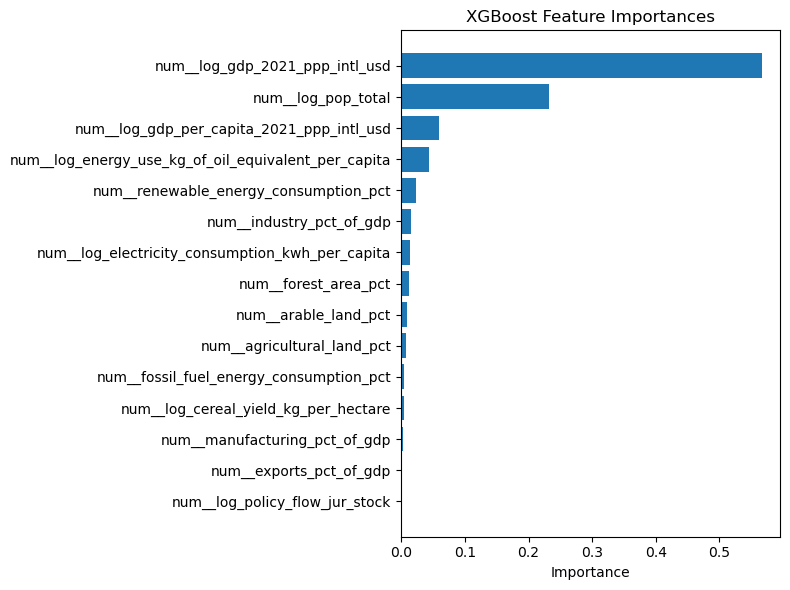

In [88]:
ra_15_feat.plot_feature_importances(model="XGBoost", top_n=15)

### Retrain 10 features

In [268]:
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "")
top_10_preds = [f"{clean_feature_name(f)}" for f in ra.top_n_features("XGBoost", 10)]
top_10_preds

['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'renewable_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_policy_flow_jur_stock',
 'industry_pct_of_gdp',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_electricity_consumption_kwh_per_capita',
 'arable_land_pct',
 'forest_area_pct']

In [269]:
retraining_fields_top10 = fixed_effect + time_var + top_10_preds  + [target]
retraining_fields_top10

['iso_alpha_3',
 'year',
 'log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'renewable_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_policy_flow_jur_stock',
 'industry_pct_of_gdp',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_electricity_consumption_kwh_per_capita',
 'arable_land_pct',
 'forest_area_pct',
 'log_total_emissions']

In [270]:
retraining_df_top10_preds = training_df_transformed[retraining_fields_top10].copy()
retraining_df_top10_preds.head()

,iso_alpha_3,year,log_gdp_2021_ppp_intl_usd,log_pop_total,renewable_energy_consumption_pct,log_energy_use_kg_of_oil_equivalent_per_capita,log_policy_flow_jur_stock,industry_pct_of_gdp,log_gdp_per_capita_2021_ppp_intl_usd,log_electricity_consumption_kwh_per_capita,arable_land_pct,forest_area_pct,log_total_emissions
0,AGO,1980,25.301042,15.911548,72.3,6.228706,1.252763,51.919652,9.032376,4.010731,2.326141,63.57807,3.307180
1,AGO,1981,25.301042,15.947972,72.3,6.228706,1.321756,51.919652,9.032376,4.010731,2.326141,63.57807,3.254307
2,AGO,1982,25.301042,15.984753,72.3,6.228706,1.386294,51.919652,9.032376,4.010731,2.326141,63.57807,3.342043
3,AGO,1983,25.301042,16.021913,72.3,6.228706,1.446919,51.919652,9.032376,4.010731,2.326141,63.57807,3.396239
4,AGO,1984,25.301042,16.058974,72.3,6.228706,1.504077,51.919652,9.032376,4.010731,2.326141,63.57807,3.410605


In [271]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra_10_feat = RegressionAnalysis(
    df=retraining_df_top10_preds,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=top_10_preds
)

ra_10_feat.cross_validate()
ra_10_feat.fit()
ra_10_feat.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3577          nan
RandomForest          0.4633       0.4041
XGBoost               0.3915       0.3602
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1073         0.1599            0.1398            0.1961               22.81               43.22
RandomForest            0.0171         0.1980            0.0298            0.3203                2.97               48.12
XGBoost                 0.0305         0.1570            0.0411            0.2238                6.44               63.37
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.10726306555819476,
  'test_mae_log': 0.1598509030244512,
  'train_rmse_log': np.float64(0.1398399583443345),
  'test_rmse_log': np.float64(0.19607338872464708),
  'train_mae_level': np.float64(22.80657114381359),
  'test_mae_level': np.float64(43.21953184626194)},
 'RandomForest': {'train_mae_log': 0.01712140864677349,
  'test_mae_log': 0.1979680406507542,
  'train_rmse_log': np.float64(0.02980099173064975),
  'test_rmse_log': np.float64(0.3202650231767811),
  'train_mae_level': np.float64(2.9662022912830404),
  'test_mae_level': np.float64(48.1210447325119)},
 'XGBoost': {'train_mae_log': 0.030467015193923856,
  'test_mae_log': 0.15703571630043253,
  'train_rmse_log': np.float64(0.0411359815010327),
  'test_rmse_log': np.float64(0.22378757956254955),
  'train_mae_level': np.float64(6.43739287817139),
  'test_mae_level': np.float64(63.36639425821121)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train_rmse

In [272]:
# Table
country_errors_10_feat = ra_10_feat.per_country_errors(model="randomForest")
country_errors_10_feat.sort_values(by="mae_level", ascending=False)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
167,IDN,6,0.998773,1.034166,2115.200457
81,CHN,6,0.113325,0.119784,1597.566241
35,USA,6,0.051805,0.058521,315.124649
169,SGP,6,1.355368,1.519311,269.838062
155,NGA,6,0.463925,0.560003,232.320690
...,...,...,...,...,...
41,GRD,6,0.054905,0.063853,0.070278
17,COM,6,0.034704,0.036301,0.063674
6,VUT,6,0.024829,0.028647,0.040138
12,VCT,6,0.030570,0.060059,0.038345


### Retrain with 15 features and total emissions lag

In [273]:
# retraining_df_top15_preds.head()

In [274]:
# # Add lag 1 to total_emissions
# retraining_df_top15_preds = retraining_df_top15_preds.sort_values(by=["iso_alpha_3", "year"])
# retraining_df_top15_preds["total_emissions_lag1"] = (
#     retraining_df_top15_preds
#     .groupby("iso_alpha_3")["log_total_emissions"]
#     .shift(1)
# )
# retraining_df_top15_preds.head()

In [275]:
# # Drop rows with NaN in total_emissions_lag1
# retraining_df_top15_preds = retraining_df_top15_preds.dropna(subset=["total_emissions_lag1"])
# retraining_df_top15_preds.head()

In [276]:
# # add lag 1 to total_emissions to top_15_preds list
# top_15_preds.append("total_emissions_lag1")
# top_15_preds

In [277]:
# xgb_params = dict(
#     n_estimators=300,      # Enough trees, not excessive for this size
#     max_depth=6,           # Controls overfitting, 4–6 is common
#     learning_rate=0.07,    # Slower learning, safer default than 0.1
#     subsample=0.8,         # Row sampling for robustness
#     colsample_bytree=0.8,  # Feature sampling per tree for robustness
#     reg_alpha=0.2,         # L1 regularization, good for tabular data
#     reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
#     random_state=42,       # For reproducibility
#     n_jobs=-1,             # Use all cores
#     verbosity=0
# )

# print("Running regression without group feature...")

# ra_15_feat_with_lag = RegressionAnalysis(
#     df=retraining_df_top15_preds,
#     target_col="log_total_emissions",
#     group_col="iso_alpha_3",
#     year_col="year",
#     holdout_years=6,
#     xgb_params=xgb_params,
#     scaler_type="minmax",
#     feature_cols=top_15_preds
# )

# ra_15_feat_with_lag.cross_validate()
# ra_15_feat_with_lag.fit()
# ra_15_feat_with_lag.evaluate()

In [278]:
# ra_15_feat_with_lag.plot_feature_importances(model="XGBoost", top_n=15)

In [279]:
# training_df[training_df['iso_alpha_3']=='USA']["total_emissions"]

In [280]:
# # Table
# country_errors_15_feat_with_lag = ra_15_feat_with_lag.per_country_errors(model="XGBoost")
# country_errors_15_feat_with_lag.sort_values(by="mae_level", ascending=False)

## 8. Save selected model

We will keep the one trained with the top 15 features as it reduced the errors and performed better in the per-country error analysis.

In [89]:
retraining_df_top15_preds.columns

Index(['iso_alpha_3', 'year', 'log_gdp_2021_ppp_intl_usd', 'log_pop_total',
       'renewable_energy_consumption_pct',
       'log_energy_use_kg_of_oil_equivalent_per_capita',
       'log_policy_flow_jur_stock', 'industry_pct_of_gdp',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_electricity_consumption_kwh_per_capita', 'arable_land_pct',
       'forest_area_pct', 'fossil_fuel_energy_consumption_pct',
       'exports_pct_of_gdp', 'manufacturing_pct_of_gdp',
       'log_cereal_yield_kg_per_hectare', 'agricultural_land_pct',
       'log_total_emissions', 'total_emissions'],
      dtype='object')

In [90]:
top_15_preds

['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'renewable_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_policy_flow_jur_stock',
 'industry_pct_of_gdp',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_electricity_consumption_kwh_per_capita',
 'arable_land_pct',
 'forest_area_pct',
 'fossil_fuel_energy_consumption_pct',
 'exports_pct_of_gdp',
 'manufacturing_pct_of_gdp',
 'log_cereal_yield_kg_per_hectare',
 'agricultural_land_pct']

In [ ]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
retraining_df_top15_preds.to_csv(
    os.path.join(TRAINING_DIR_PATH, "training_df_top15_preds_with_raw_emissions.csv"),
    index=False
)

retraining_df_top15_preds.to_csv(
    os.path.join(TRAINING_DIR_PATH, "training_df_top15_preds.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "xgboost_top15": ra_15_feat.pipe_xgb,   # <- THIS is the key line
}

rewrite_existing_models = False

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)

Overwriting existing model at /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/xgboost_top15_pipeline.pkl
